In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os
import sys
import json

import argparse

from dataclasses import dataclass

In [3]:

from matplotlib import rcParams
from matplotlib import font_manager
%matplotlib inline

In [4]:
# resource configuration
rcParams['figure.dpi'] = 200

# fount information
rcParams['font.family'] = 'Equinor'
rcParams['font.size'] = 9

# fornt location
font_path = r'Equinor_regular'
font_files = font_manager.findSystemFonts(fontpaths=font_path)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

In [5]:
# where WellClass and Ga[ codes are located
sys.path.append('../')

In [6]:
from pathlib import Path

from src.WellClass.libs.well_class import WellProcessed
from src.WellClass.libs.grid_utils import LGRBuilder, WellDataFrame
from src.WellClass.libs.plotting import plot_grid, plot_sketch

## Some user options

In [7]:
# TODO(hzh): use Ali's algorithm
Ali_way = False
# Ali_way = True


In [8]:
# The canonical workflow consumes WellClass JSON directly.
use_yaml = False

In [9]:
# Select the canonical JSON well and matching coarse simulator grid.
case_type = 'wildcat'

In [10]:
root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent

## Examples

In [11]:
examples = {
    'wildcat': {
        'well_json': root / 'test_data/examples/wildcat/wildcat.json',
        'sim_path': root / 'test_data/examples/wildcat',
        'simcase': 'TEMP-0',
    },
    'smeaheia': {
        'well_json': root / 'test_data/examples/smeaheia/smeaheia.json',
        'sim_path': root / 'test_data/examples/smeaheia',
        'simcase': 'TEMP-0',
    },
}

In [12]:

@dataclass                # @dataclass(kw_only=True)
class Arguments:
    ali_way: bool
    use_yaml: bool
    case_type: str
    output_dir: str = '.'
    output_name: str = 'LEG_HIRES'
    plot: bool = True

In [13]:

args = Arguments(ali_way=Ali_way, use_yaml=use_yaml, case_type=case_type)

In [14]:
Ali_way = args.ali_way
case_type = args.case_type
output_dir = Path(args.output_dir)
LGR_NAME = args.output_name

In [15]:
case = examples[case_type]
sim_path = Path(case['sim_path'])
well_json = Path(case['well_json'])
simcase = sim_path / 'model' / case['simcase']
print('well JSON:', well_json)
print('grid case:', simcase)

well JSON: /workspaces/SCREEN/test_data/examples/wildcat/wildcat.json
grid case: /workspaces/SCREEN/test_data/examples/wildcat/model/TEMP-0


## Load well configuration file

## JSON-to-LGR workflow

```mermaid
flowchart LR
    JSON[Canonical well JSON] --> Validate[WellModel validation]
    Validate --> Process[WellProcessed]
    Process --> Geometry[Well geometry and TVD intervals]
    Geometry --> Adapter[WellDataFrame]
    Adapter --> Inputs[GaP geometry frames]
    Grid[Coarse EGRID and INIT] --> Builder[LGRBuilder]
    Inputs --> Builder
    Builder --> Refine[Grid refinement and material assignment]
    Refine --> Artifact[CARFIN / LGR GRDECL]
    Process --> QC[WellClass sketch]
    Refine --> QC2[Coarse and refined grid plots]
```

The JSON is the single well-input contract in this workflow. YAML, CSV, and spreadsheet formats are upstream formats that can be converted into this structure separately.

In [16]:
processed_well = WellProcessed.from_json(well_json)
print('processed well:', processed_well.header['unique_wellbore_identifier'])

processed well: NO 17/4-1


## Build well class

In [17]:
well_frames = WellDataFrame(
    processed_well,
    oh_perm=10000.0,
    cb_perm=0.05,
    barrier_perm=0.05,
)

annulus_df = well_frames.annulus_df
holes_df = well_frames.holes_df
casings_df = well_frames.casings_df
barrier_regions_df = well_frames.barrier_regions_df

print({
    'holes': len(holes_df),
    'casings': len(casings_df),
    'barrier_regions': len(barrier_regions_df),
})

{'holes': 5, 'casings': 3, 'barrier_regions': 4}


In [18]:
# The adapter is the compatibility boundary between WellClass and GaP.
assert holes_df is well_frames.drilling_df
assert processed_well.header['unique_wellbore_identifier']

## Build LGR grids

In [19]:
lgr = LGRBuilder(simcase, annulus_df, holes_df, Ali_way)
print({
    'coarse_dimensions': (lgr.grid_coarse.NX, lgr.grid_coarse.NY, lgr.grid_coarse.NZ),
    'refined_dimensions': (lgr.grid_refine.nx, lgr.grid_refine.ny, lgr.grid_refine.nz),
})

Coarse grid dimension: nx=20, ny=20, nz=60
Minimimum grid size is 5.24 cm
LGR dimension: nx=22, ny=22, nz=150


{'coarse_dimensions': (20, 20, 60), 'refined_dimensions': (22, 22, 150)}


In [20]:
gap_casing_df = lgr.build_grdecl(
    str(output_dir),
    LGR_NAME,
    holes_df,
    casings_df,
    barrier_regions_df,
)
output_file = output_dir / f'{LGR_NAME}.grdecl'
print('GRDECL:', output_file)
print('exists:', output_file.exists())
assert output_file.exists()

...Prints isolating OVB from reservoir keywords in LEG_HIRES.grdecl file
...Prints CARFIN Keywords in LEG_HIRES.grdecl file
...Prints isolating OVB from reservoir in the LGR in LEG_HIRES.grdecl file
...reopenID = 12.25 ...
Output LGR CARFIN to:  /workspaces/SCREEN/notebooks/LEG_HIRES.grdecl
GRDECL: LEG_HIRES.grdecl
exists: True


# Visualization

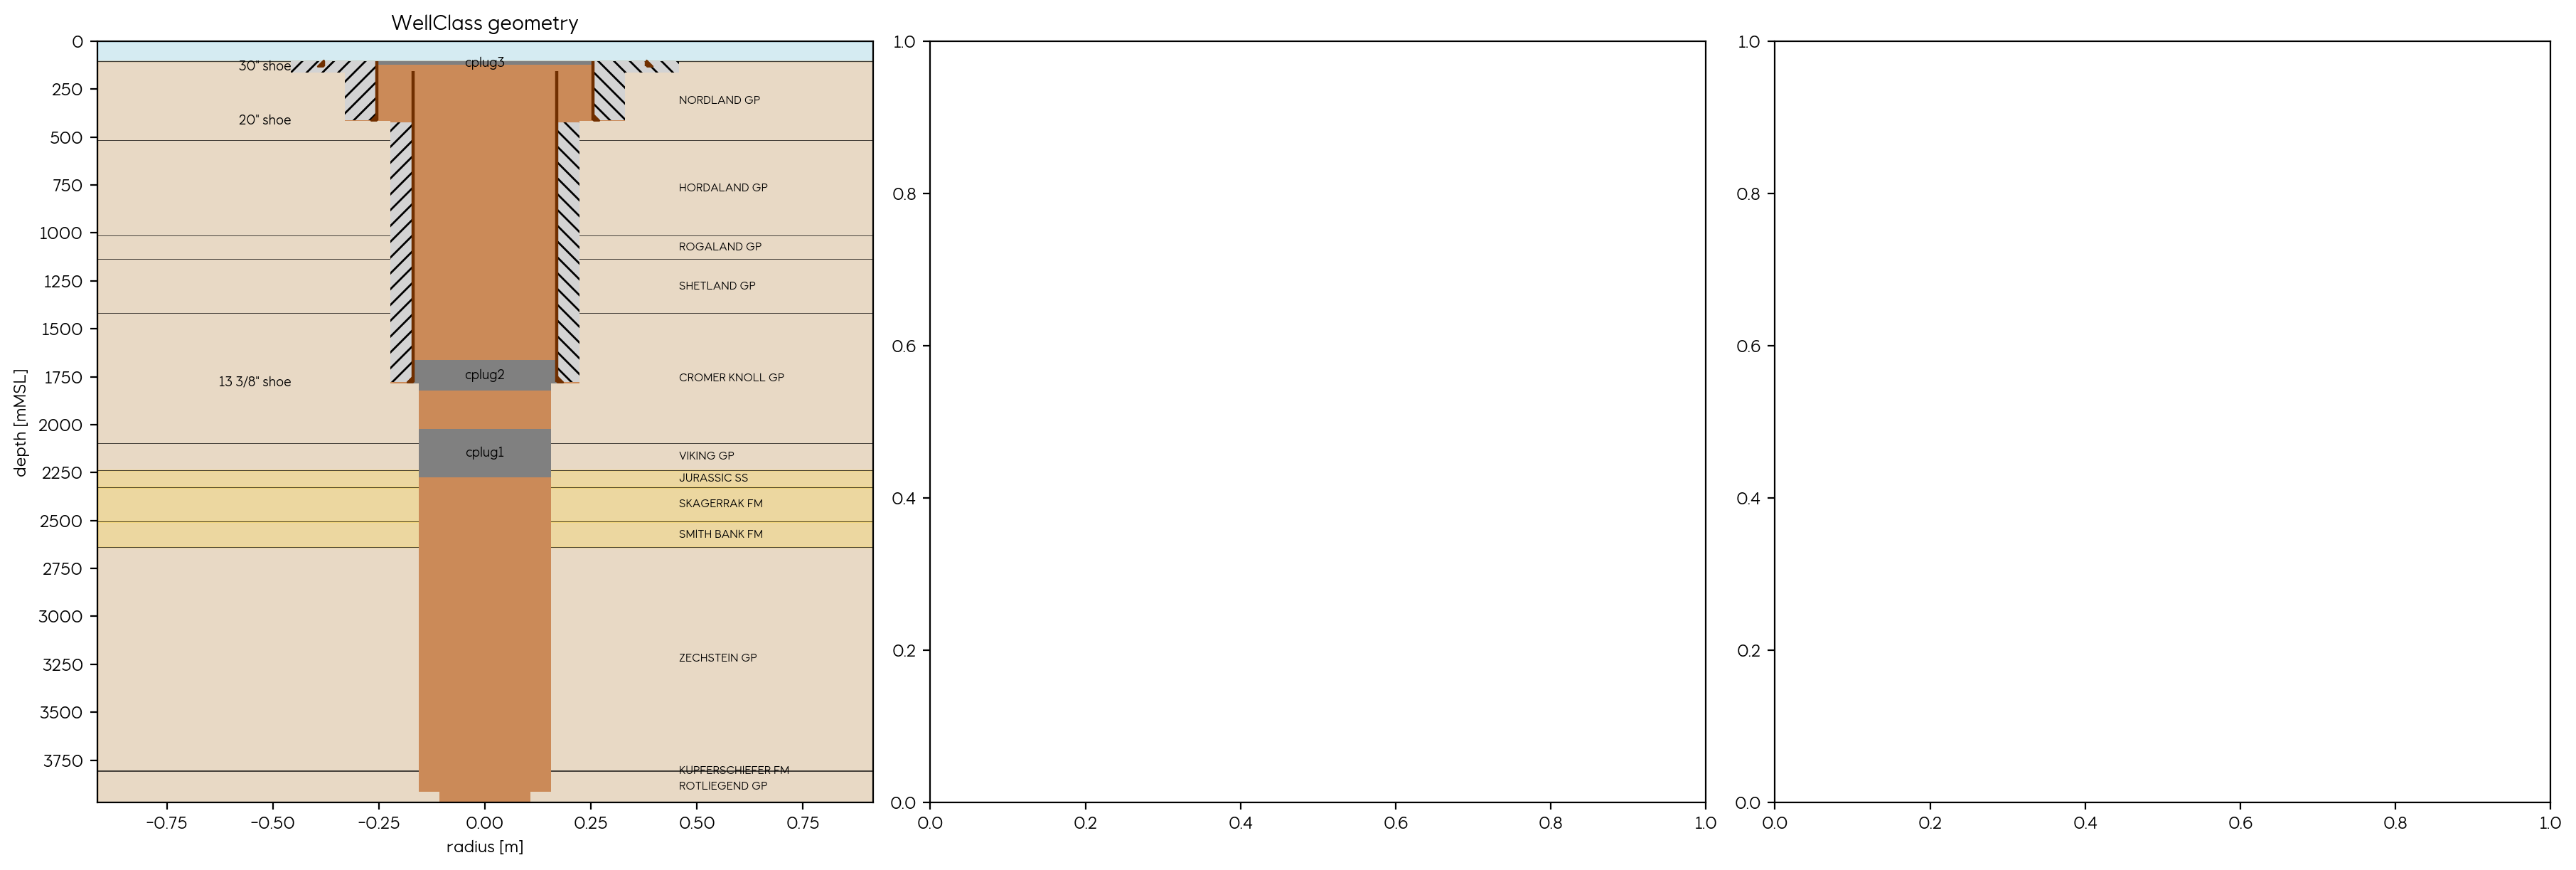

<Figure size 1400x1200 with 0 Axes>

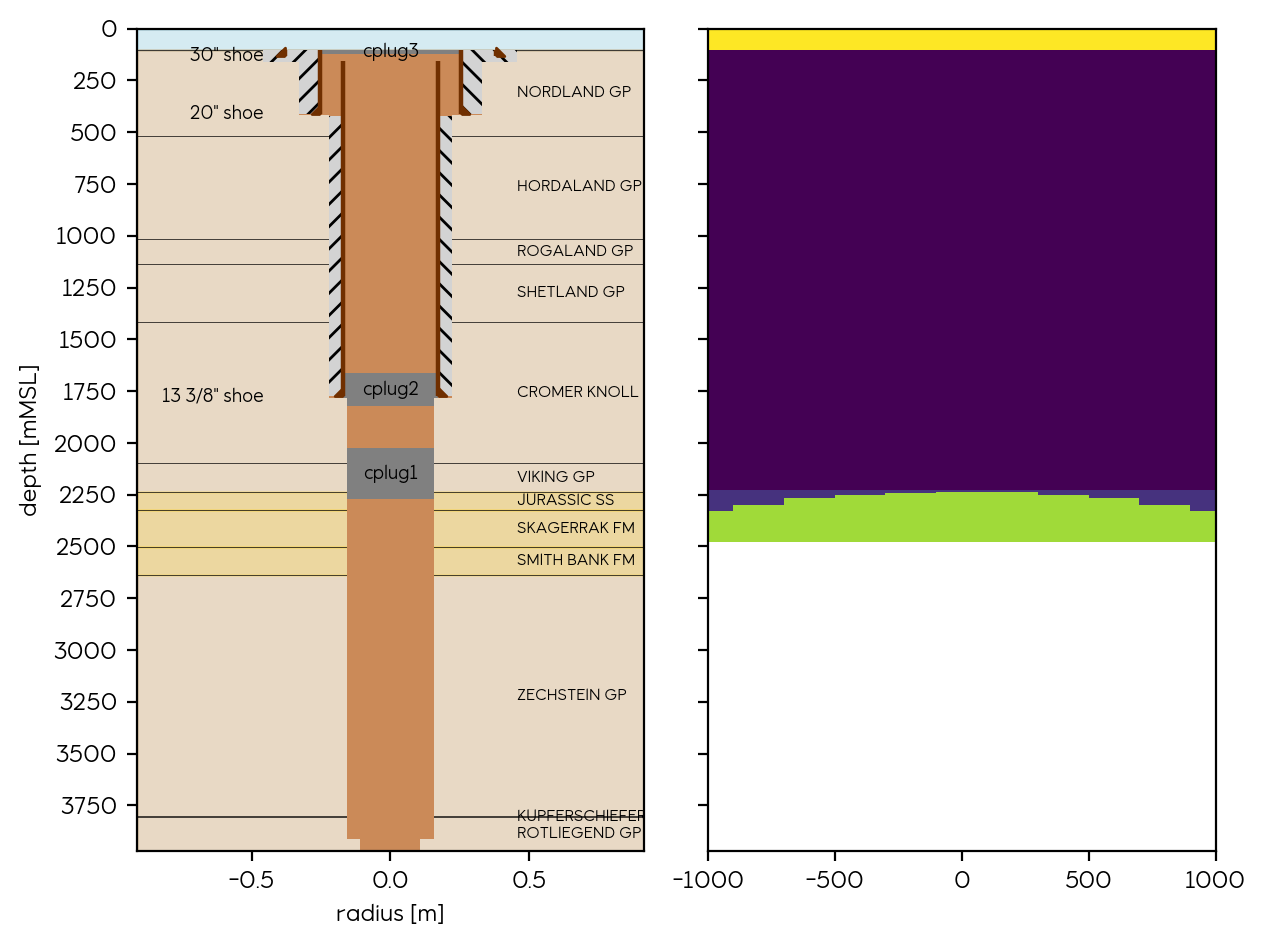

<Figure size 1280x960 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

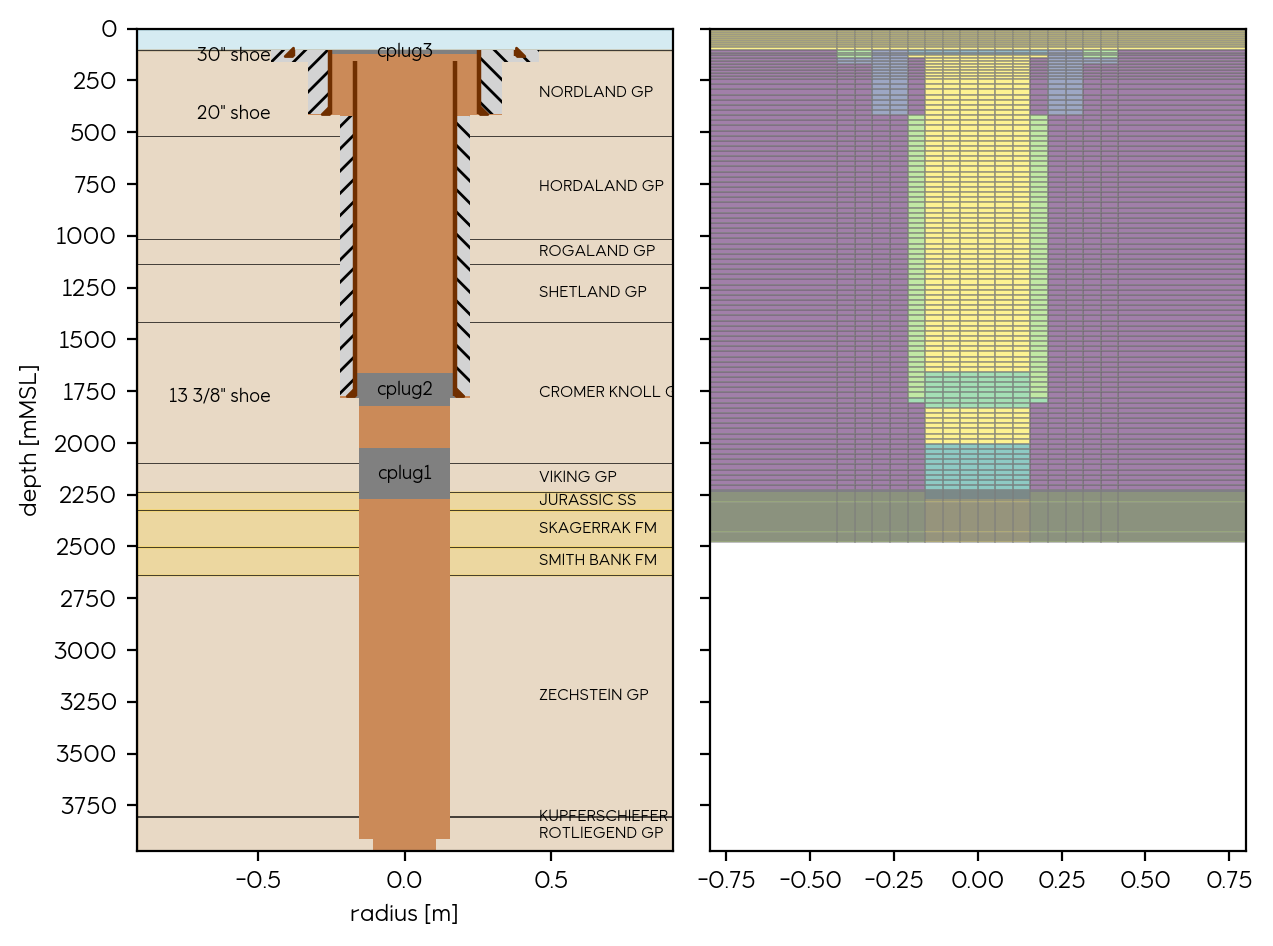

<Figure size 1280x960 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# WellClass-only view: the physical well construction before grid mapping.
plot_sketch(processed_well, ax=axes[0])
axes[0].set_title('WellClass geometry')

# GaP coarse grid with the WellClass sketch overlaid by plot_grid.
plt.figure(figsize=(7, 6))
plot_grid(processed_well, lgr.grid_coarse, on_coarse=True)
plt.suptitle('Coarse grid with WellClass well')

# The refined grid uses the same WellClass object and shows the LGR resolution.
plt.figure(figsize=(7, 6))
plot_grid(processed_well, lgr.grid_refine, on_coarse=False)
plt.suptitle('Refined LGR with WellClass well')

plt.show()

In [22]:
# The two plot_grid calls above intentionally use the same processed well:
# one overlays it on the coarse grid, and the other overlays it on the refined LGR.
assert lgr.grid_coarse is not lgr.grid_refine
print('WellClass overlay shown on coarse and refined grids.')

WellClass overlay shown on coarse and refined grids.


# Pytest

In [23]:
# flags for pytest unit/integration testing

# save data for pytest
PYTEST_FLAG = False 


In [24]:

# NOTE: please try not to change the followings, unless you know what you are doing

# Note: only handle wildcat case for simplicity
CASE_TEST = case_type == 'wildcat'

# where to save pytest data
PYTEST_FOLDER = 'pytest'


In [25]:

# determine pytest flag
PYTEST_SAVE = CASE_TEST and PYTEST_FLAG

In [26]:

if PYTEST_SAVE:
    # Note: have to use pickle to keep integer key as integer
    import pickle
    import pathlib

    # folder to save pytest data
    pytest_path = pathlib.Path(sim_path)/PYTEST_FOLDER

    # build the folder if it doesn't exist
    # NOTE: I intentionally make the 'parents=False'
    pytest_path.mkdir(parents=False, exist_ok=True)

In [27]:
# save WellClass for pytest unit/integration testing
if PYTEST_SAVE:
    #
    well_input_name = case['well_input_yaml'].replace('.yaml', '_well_pytest.pkl')
    well_dict_name = pytest_path/well_input_name
    
    with open(well_dict_name, 'wb') as pkl_file:
        pickle.dump(my_well.__dict__, pkl_file)

In [28]:
# save WellClass dataframe for pytest unit/integration testing
if PYTEST_SAVE:
    #
    well_input_name = case['well_input_yaml'].replace('.yaml', '_lgr_pytest.pkl')
    lgr_dict_name = pytest_path/well_input_name
    
    with open(lgr_dict_name, 'wb') as pkl_file:
        pickle.dump(lgr.__dict__, pkl_file)